In [2]:
!pip install qiskit
!pip install qiskit-aer

In [2]:
from qiskit import QuantumCircuit,transpile
from qiskit_aer import Aer

In [3]:
from qiskit.visualization import *

In [4]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all(range(2),range(2))

qc.draw()

┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        └───┘┌─┴─┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├─░──╫─┤M├
             └───┘ ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1

In [5]:
backend = Aer.get_backend('qasm_simulator')
compiled_circuit = transpile(qc, backend)

job = backend.run(compiled_circuit,shots=1000)

result = job.result()
counts = result.get_counts()
print(counts)

{'11': 485, '00': 515}


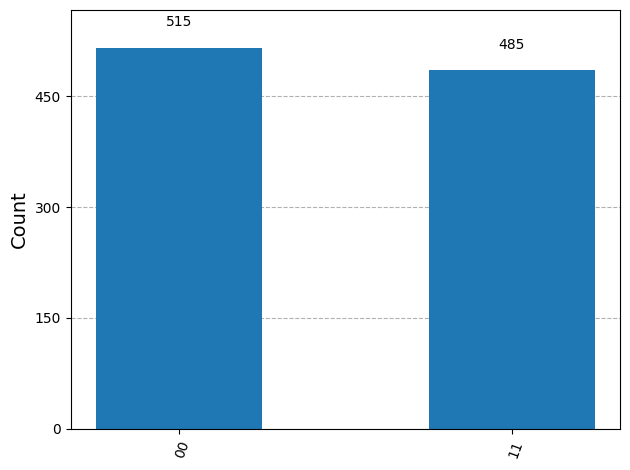

In [6]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)

In [7]:
from qiskit.visualization import plot_state_qsphere
from qiskit.visualization import plot_bloch_multivector

In [8]:
qc=QuantumCircuit(2)

In [9]:
statevector_simulator=Aer.get_backend("statevector_simulator")
compiled_circuit=transpile(qc,statevector_simulator)

job = statevector_simulator.run(compiled_circuit)
result = job.result()

In [10]:
statevector_results=result.get_statevector(qc)

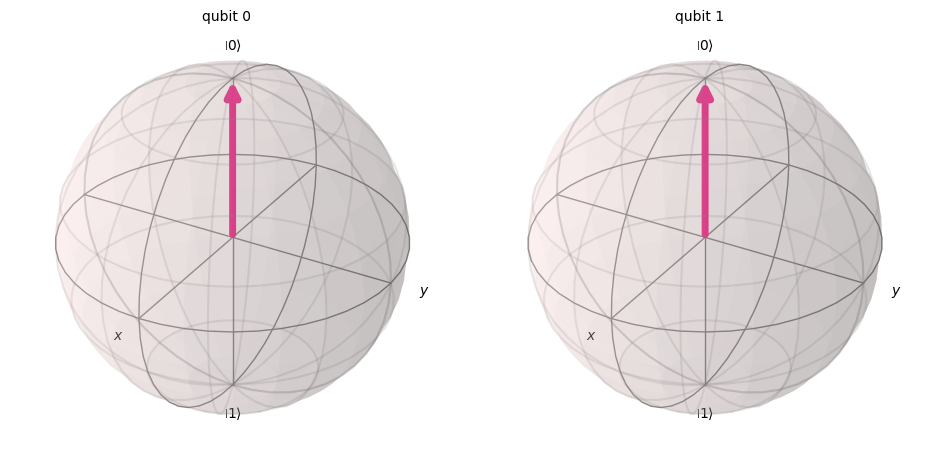

In [11]:
plot_bloch_multivector(statevector_results)

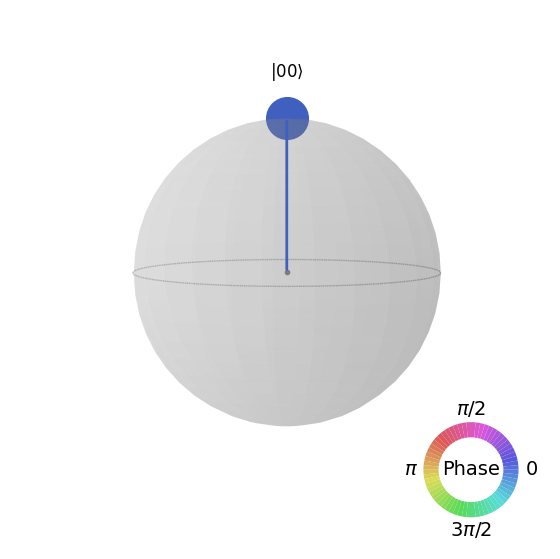

In [12]:
plot_state_qsphere(statevector_results)

In [24]:
qc.x(0)

In [29]:
statevector_simulator=Aer.get_backend("statevector_simulator")
compiled_circuit=transpile(qc,statevector_simulator)

job = statevector_simulator.run(compiled_circuit)
result = job.result()

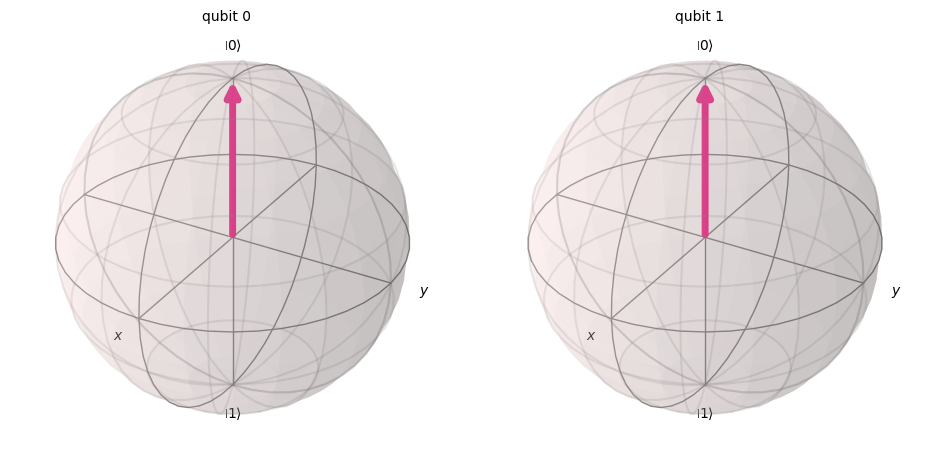

In [30]:
plot_bloch_multivector(statevector_results)

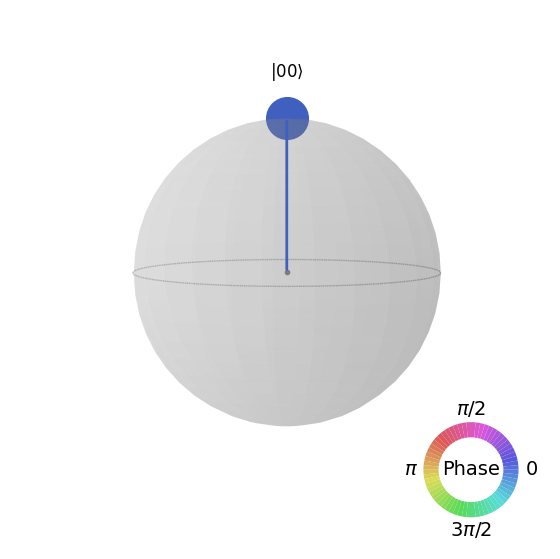

In [31]:
plot_state_qsphere(statevector_results)

## Quantum Teleportation

In [9]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, plot_bloch_multivector, array_to_latex

## Deutsch Algorithm

In [13]:
from qiskit import QuantumCircuit,transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

In [7]:
def deutsch_oracle(case):
    qc=QuantumCircuit(2)
    if case=="constant_0":  
        pass
    elif case=="constant_1": 
        qc.x(1)
    elif case=="balanced_0": 
        qc.cx(0,1)
    elif case=="balanced_1": 
        qc.x(0)
        qc.cx(0,1)
        qc.x(0)
    return qc

In [16]:
def deutsch_algorithm(case):
    qc=QuantumCircuit(2,1) 
    qc.x(1)
    
    qc.h([0,1])

    qc.barrier()
    qc.compose(deutsch_oracle(case),inplace=True)
    qc.barrier()

    qc.h(0)

    qc.measure(0,0)
    qc.draw()

    return qc

for case in ["constant_0","constant_1","balanced_0","balanced_1"]:
    qc=deutsch_algorithm(case)
    simulator=Aer.get_backend("qasm_simulator")
    compiled_circuit=transpile(qc,simulator)
    job=simulator.run(compiled_circuit,shots=1024)
    result=job.result()
    counts=result.get_counts()
    print(f"Case:{case},Result:{counts}")

Case:constant_0,Result:{'0': 1024}
Case:constant_1,Result:{'0': 1024}
Case:balanced_0,Result:{'1': 1024}
Case:balanced_1,Result:{'1': 1024}


In [9]:
qc.draw()

┌───┐ ░ ┌───┐     ┌───┐ ░ ┌───┐┌─┐
q_0: ┤ H ├─░─┤ X ├──■──┤ X ├─░─┤ H ├┤M├
     ├───┤ ░ └───┘┌─┴─┐└───┘ ░ └───┘└╥┘
q_1: ┤ H ├─░──────┤ X ├──────░───────╫─
     └───┘ ░      └───┘      ░       ║ 
c: 1/════════════════════════════════╩═
                                     0

### Deutsch Jozsa Algorithm

In [3]:
from qiskit import QuantumCircuit,transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

In [10]:
def deutsch_jozsa_oracle(case,n):
    qc=QuantumCircuit(n+1)
    if case=="constant_0": 
        pass
    elif case=="constant_1":
        qc.x(n)
    elif case=="balanced": 
        for qubit in range(n):
            qc.cx(qubit, n)
    return qc

In [11]:
def deutsch_jozsa_algorithm(case,n):
    qc=QuantumCircuit(n+1,n) 
    qc.x(n)  
    
    qc.h(range(n+1))
    
    qc.barrier()
    qc.compose(deutsch_jozsa_oracle(case,n),inplace=True)
    qc.barrier()
    
    qc.h(range(n))
    
    qc.measure(range(n),range(n))
    
    return qc

n=5  

for case in ["constant_0","constant_1","balanced"]:
    qc=deutsch_jozsa_algorithm(case,n)
    simulator=Aer.get_backend("qasm_simulator")
    compiled_circuit=transpile(qc,simulator)
    job=simulator.run(compiled_circuit,shots=1024)
    result=job.result()
    counts = result.get_counts()
    
    print(f"Case: {case}, Measurement: {counts}")
    qc.draw()
    plt.show()
    plot_histogram(counts)
    plt.show()

Case: constant_0, Measurement: {'00000': 1024}
Case: constant_1, Measurement: {'00000': 1024}
Case: balanced, Measurement: {'11111': 1024}


In [12]:
qc.draw()

┌───┐      ░                           ░ ┌───┐┌─┐            
q_0: ┤ H ├──────░───■───────────────────────░─┤ H ├┤M├────────────
     ├───┤      ░   │                       ░ ├───┤└╥┘┌─┐         
q_1: ┤ H ├──────░───┼────■──────────────────░─┤ H ├─╫─┤M├─────────
     ├───┤      ░   │    │                  ░ ├───┤ ║ └╥┘┌─┐      
q_2: ┤ H ├──────░───┼────┼────■─────────────░─┤ H ├─╫──╫─┤M├──────
     ├───┤      ░   │    │    │             ░ ├───┤ ║  ║ └╥┘┌─┐   
q_3: ┤ H ├──────░───┼────┼────┼────■────────░─┤ H ├─╫──╫──╫─┤M├───
     ├───┤      ░   │    │    │    │        ░ ├───┤ ║  ║  ║ └╥┘┌─┐
q_4: ┤ H ├──────░───┼────┼────┼────┼────■───░─┤ H ├─╫──╫──╫──╫─┤M├
     ├───┤┌───┐ ░ ┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐ ░ └───┘ ║  ║  ║  ║ └╥┘
q_5: ┤ X ├┤ H ├─░─┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├─░───────╫──╫──╫──╫──╫─
     └───┘└───┘ ░ └───┘└───┘└───┘└───┘└───┘ ░       ║  ║  ║  ║  ║ 
c: 5/═══════════════════════════════════════════════╩══╩══╩══╩══╩═
                                                    0  1  2  3  4